# Baseline Modeling
## Respiratory Disease Prediction from Environmental Factors

## Scope

This notebook covers the baseline model for the March check-in only.
More complex models (Random Forest, XGBoost) are planned for the April check-in.

## What we are predicting

**Target:** `pct_respiratory` — daily percentage of US emergency department visits
classified as Acute Respiratory Illness (ARI), sourced from CDC NSSP.

We use percentage rather than raw counts because it normalizes for hospital
capacity variation over time and is the standard metric in syndromic surveillance.

## Feature set (from EDA)

| Feature | Type | Justification from EDA |
|---|---|---|
| temperature | Same-day | Strongest predictor (r = -0.812), no lag benefit |
| humidity | Same-day | r = +0.530, no lag benefit |
| no2_lag12 | 12-day lag | r improves from 0.640 to 0.743 with lag |
| ozone_lag13 | 13-day lag | r improves from -0.656 to -0.732 with lag |
| pm25_lag14 | 14-day lag | Weakest feature (r = -0.153), included for completeness |
| month | Temporal | Seasonality explains 81.4% of variance |
| day_of_week | Temporal | Day-of-week effect confirmed statistically significant |

## Input

`data/processed/features_daily.csv` — 1,119 rows with all lagged features

## Output

```
outputs/figures/
    model_01_actual_vs_predicted.png
    model_02_residuals.png
    model_03_feature_coefficients.png
```

## Setup

In [3]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

TARGET = 'pct_respiratory'

# Feature set determined by EDA lag analysis
# Each feature and its justification is documented above
MODEL_FEATURES = [
    'temperature',    # r = -0.812, lag-0 is optimal
    'humidity',       # r = +0.530, lag-0 is optimal
    'no2_lag12',      # r improves from 0.640 to 0.743 at lag-12
    'ozone_lag13',    # r improves from -0.656 to -0.732 at lag-13
    'pm25_lag14',     # weakest feature, r = -0.153 at lag-14
    'month',          # seasonality explains 81.4% of variance
    'day_of_week',    # statistically significant day-of-week effect
]

FEATURE_LABELS = {
    'temperature': 'Temperature (F)',
    'humidity':    'Humidity (%)',
    'no2_lag12':   'NO2 lag-12 (ppb)',
    'ozone_lag13': 'Ozone lag-13 (ppm)',
    'pm25_lag14':  'PM2.5 lag-14 (ug/m3)',
    'month':       'Month',
    'day_of_week': 'Day of Week',
}

# Load features dataset
df = pd.read_csv('data/processed/features_daily.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Features dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'\nFeatures used in model: {MODEL_FEATURES}')
print(f'Target: {TARGET}')

Features dataset: 1119 rows x 14 columns
Date range: 2022-10-09 to 2025-10-31

Features used in model: ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month', 'day_of_week']
Target: pct_respiratory


---
## Step 1: Train/Test Split

**Time-ordered split - no shuffling.**

Standard random splits cannot be used for time series data because they would allow
future data to leak into training. We train on the first 80% of the time series
and test on the final 20%. This simulates the real-world use case of predicting
future respiratory illness from past environmental data.

In [4]:
# Prepare data
model_data = df[['date'] + MODEL_FEATURES + [TARGET]].dropna().reset_index(drop=True)

X = model_data[MODEL_FEATURES].values
y = model_data[TARGET].values
dates = model_data['date']

# Time-ordered 80/20 split
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train     = dates[:split_idx]
dates_test      = dates[split_idx:]

print(f'Total rows:  {len(model_data)}')
print(f'Train rows:  {len(X_train)}  ({dates_train.min().date()} to {dates_train.max().date()})')
print(f'Test rows:   {len(X_test)}   ({dates_test.min().date()} to {dates_test.max().date()})')
print(f'\nTrain target range: {y_train.min():.2f}% to {y_train.max():.2f}%')
print(f'Test target range:  {y_test.min():.2f}% to {y_test.max():.2f}%')

Total rows:  1119
Train rows:  895  (2022-10-09 to 2025-03-21)
Test rows:   224   (2025-03-22 to 2025-10-31)

Train target range: 7.49% to 26.58%
Test target range:  7.09% to 14.14%


---
## Step 2: Baseline: Linear Regression

Linear regression is the correct starting point because:
- Coefficients are directly interpretable
- Performance gives a lower bound to beat with more complex models
- Simple enough to explain all design decisions at the check-in

We fit two versions:
1. **Without seasonal features** : shows raw environmental signal only
2. **With seasonal features** : shows full model including month and day-of-week

This demonstrates the 81.4% seasonal variance finding from EDA directly.

In [5]:
def fit_and_evaluate(X_tr, X_te, y_tr, y_te, feature_names, label):
    """Fit linear regression, evaluate, and return predictions and metrics."""
    model = LinearRegression()
    model.fit(X_tr, y_tr)

    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'r2_train':   r2_score(y_tr, y_pred_train),
        'r2_test':    r2_score(y_te, y_pred_test),
        'rmse_test':  np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'mae_test':   mean_absolute_error(y_te, y_pred_test),
        'coefficients': dict(zip(feature_names, model.coef_)),
        'intercept':  model.intercept_,
        'y_pred_test': y_pred_test,
        'y_pred_train': y_pred_train,
    }

    print(f'\n--- {label} ---')
    print(f'  Train R2:   {metrics["r2_train"]:.4f}')
    print(f'  Test  R2:   {metrics["r2_test"]:.4f}')
    print(f'  Test  RMSE: {metrics["rmse_test"]:.4f} percentage points')
    print(f'  Test  MAE:  {metrics["mae_test"]:.4f} percentage points')

    return model, metrics


# Model A: environmental features only (no month, no day_of_week)
ENV_FEATURES = ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14']
idx_env = [MODEL_FEATURES.index(f) for f in ENV_FEATURES]

model_env, metrics_env = fit_and_evaluate(
    X_train[:, idx_env], X_test[:, idx_env],
    y_train, y_test,
    ENV_FEATURES,
    'Model A: Environmental Features Only'
)

# Model B: full feature set including seasonal and temporal
model_full, metrics_full = fit_and_evaluate(
    X_train, X_test,
    y_train, y_test,
    MODEL_FEATURES,
    'Model B: Full Feature Set (env + month + day_of_week)'
)

print('\n--- Comparison ---')
print(f'  Adding month + day_of_week improves test R2 by: '
      f'{metrics_full["r2_test"] - metrics_env["r2_test"]:+.4f}')
print(f'  Adding month + day_of_week reduces RMSE by: '
      f'{metrics_env["rmse_test"] - metrics_full["rmse_test"]:+.4f} percentage points')


--- Model A: Environmental Features Only ---
  Train R2:   0.7544
  Test  R2:   -0.6268
  Test  RMSE: 1.9291 percentage points
  Test  MAE:  1.5454 percentage points

--- Model B: Full Feature Set (env + month + day_of_week) ---
  Train R2:   0.7893
  Test  R2:   -0.6980
  Test  RMSE: 1.9708 percentage points
  Test  MAE:  1.4598 percentage points

--- Comparison ---
  Adding month + day_of_week improves test R2 by: -0.0712
  Adding month + day_of_week reduces RMSE by: -0.0418 percentage points


---
## Step 3: Coefficients

Interpret what the model learned.

In [6]:
print('Model B Coefficients (full model):')
print(f'  Intercept: {metrics_full["intercept"]:.4f}')
print()
print(f'  {"Feature":<25} {"Coefficient":>12}  Interpretation')
print('  ' + '-' * 65)

interpretations = {
    'temperature': 'Each 1F rise reduces respiratory visits',
    'humidity':    'Each 1% rise in humidity increases visits',
    'no2_lag12':   'Each 1ppb NO2 12 days ago increases visits',
    'ozone_lag13': 'Each 1ppm ozone 13 days ago reduces visits',
    'pm25_lag14':  'Each 1ug/m3 PM2.5 14 days ago changes visits',
    'month':       'Each month later in year changes visits',
    'day_of_week': 'Each day later in week changes visits',
}

coef_sorted = sorted(
    metrics_full['coefficients'].items(),
    key=lambda x: abs(x[1]),
    reverse=True
)
for feat, coef in coef_sorted:
    interp = interpretations.get(feat, '')
    print(f'  {FEATURE_LABELS.get(feat, feat):<25} {coef:>+12.6f}  {interp}')

Model B Coefficients (full model):
  Intercept: 20.5109

  Feature                    Coefficient  Interpretation
  -----------------------------------------------------------------
  Ozone lag-13 (ppm)         -161.028329  Each 1ppm ozone 13 days ago reduces visits
  NO2 lag-12 (ppb)             +0.369042  Each 1ppb NO2 12 days ago increases visits
  Month                        +0.230241  Each month later in year changes visits
  Temperature (F)              -0.145639  Each 1F rise reduces respiratory visits
  Day of Week                  +0.102650  Each day later in week changes visits
  Humidity (%)                 +0.032581  Each 1% rise in humidity increases visits
  PM2.5 lag-14 (ug/m3)         -0.001447  Each 1ug/m3 PM2.5 14 days ago changes visits


---
## Step 4: Visualizations

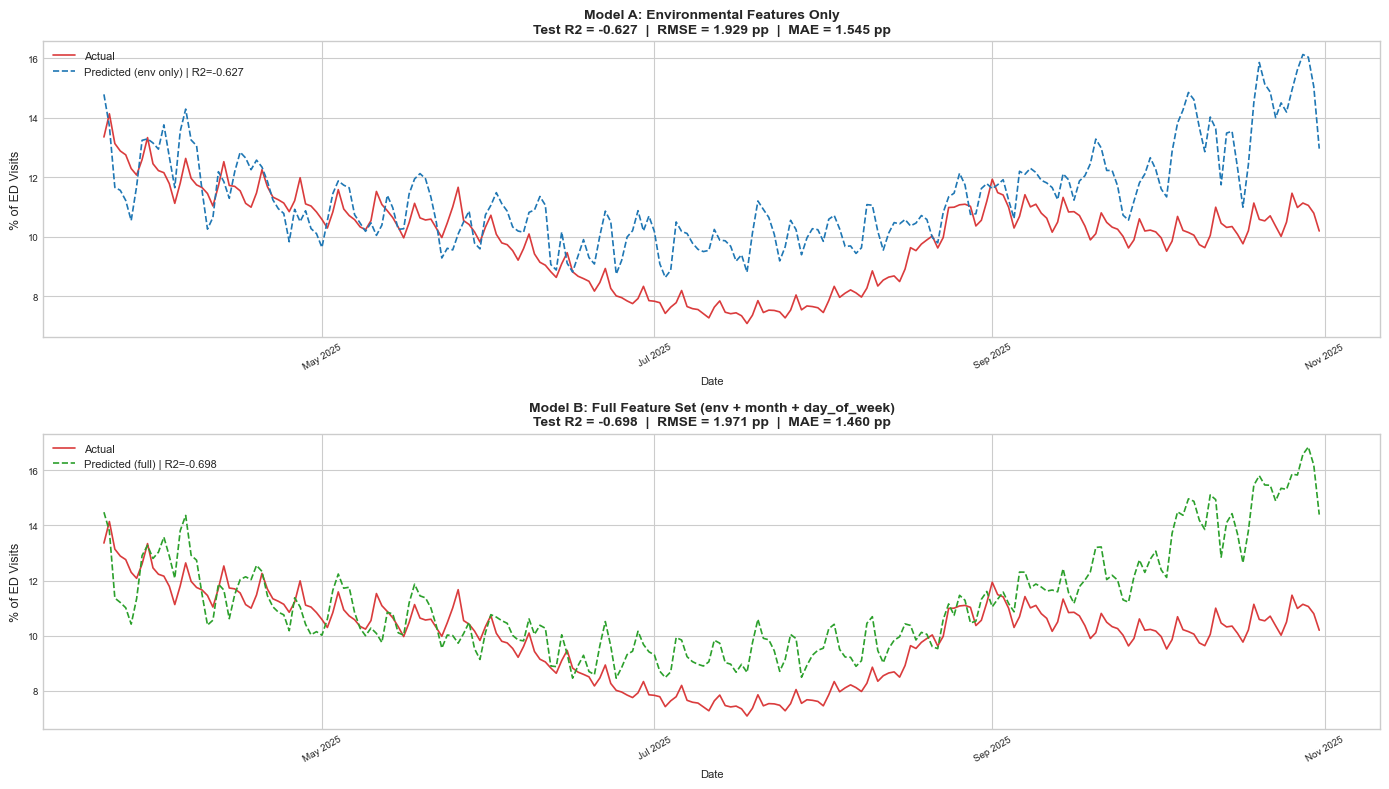

Saved: outputs/figures/model_01_actual_vs_predicted.png


In [7]:
# Plot 1: Actual vs Predicted on test set
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Model A (env only)
axes[0].plot(dates_test.values, y_test,
             color='#d62728', linewidth=1.2, label='Actual', alpha=0.9)
axes[0].plot(dates_test.values, metrics_env['y_pred_test'],
             color='#1f77b4', linewidth=1.2, linestyle='--',
             label=f'Predicted (env only) | R2={metrics_env["r2_test"]:.3f}')
axes[0].set_ylabel('% of ED Visits', fontsize=9)
axes[0].set_title(
    f'Model A: Environmental Features Only\n'
    f'Test R2 = {metrics_env["r2_test"]:.3f}  |  RMSE = {metrics_env["rmse_test"]:.3f} pp  |  '
    f'MAE = {metrics_env["mae_test"]:.3f} pp',
    fontsize=10, fontweight='bold'
)
axes[0].legend(fontsize=8)

# Model B (full)
axes[1].plot(dates_test.values, y_test,
             color='#d62728', linewidth=1.2, label='Actual', alpha=0.9)
axes[1].plot(dates_test.values, metrics_full['y_pred_test'],
             color='#2ca02c', linewidth=1.2, linestyle='--',
             label=f'Predicted (full) | R2={metrics_full["r2_test"]:.3f}')
axes[1].set_ylabel('% of ED Visits', fontsize=9)
axes[1].set_title(
    f'Model B: Full Feature Set (env + month + day_of_week)\n'
    f'Test R2 = {metrics_full["r2_test"]:.3f}  |  RMSE = {metrics_full["rmse_test"]:.3f} pp  |  '
    f'MAE = {metrics_full["mae_test"]:.3f} pp',
    fontsize=10, fontweight='bold'
)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlabel('Date', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/model_01_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_01_actual_vs_predicted.png')

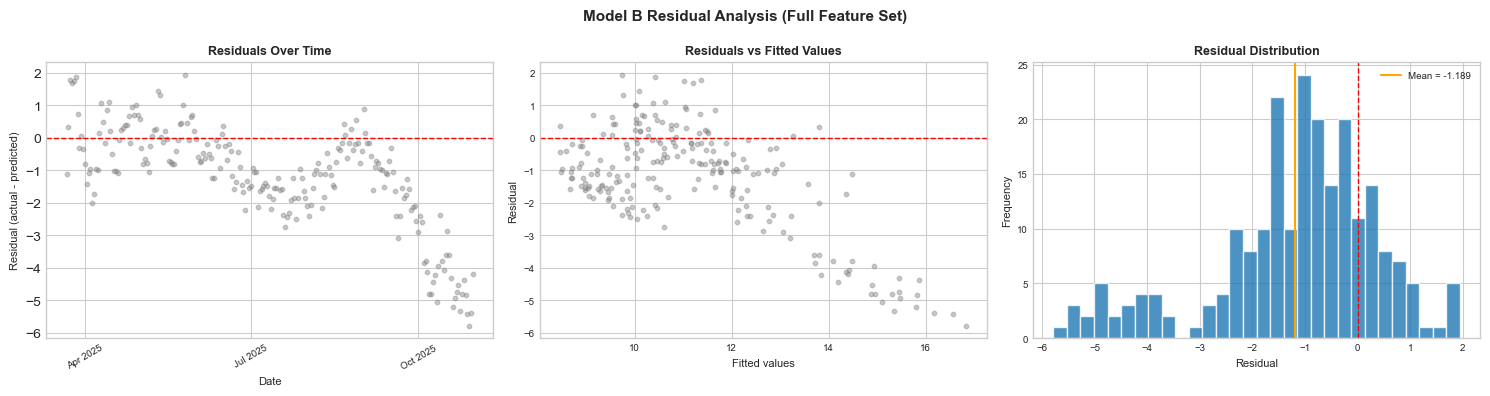

Saved: outputs/figures/model_02_residuals.png


In [8]:
# Plot 2: Residuals analysis for Model B
residuals = y_test - metrics_full['y_pred_test']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].scatter(dates_test.values, residuals, alpha=0.4, s=10, color='#7f7f7f')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title('Residuals Over Time', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=8)
axes[0].set_ylabel('Residual (actual - predicted)', fontsize=8)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(labelsize=7, axis='x', rotation=30)

# Residuals vs fitted
axes[1].scatter(metrics_full['y_pred_test'], residuals, alpha=0.4, s=10, color='#7f7f7f')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_title('Residuals vs Fitted Values', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Fitted values', fontsize=8)
axes[1].set_ylabel('Residual', fontsize=8)
axes[1].tick_params(labelsize=7)

# Residual distribution
axes[2].hist(residuals, bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linewidth=1, linestyle='--')
axes[2].axvline(residuals.mean(), color='orange', linewidth=1.5,
                label=f'Mean = {residuals.mean():.3f}')
axes[2].set_title('Residual Distribution', fontsize=9, fontweight='bold')
axes[2].set_xlabel('Residual', fontsize=8)
axes[2].set_ylabel('Frequency', fontsize=8)
axes[2].legend(fontsize=7)
axes[2].tick_params(labelsize=7)

fig.suptitle('Model B Residual Analysis (Full Feature Set)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/model_02_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_02_residuals.png')

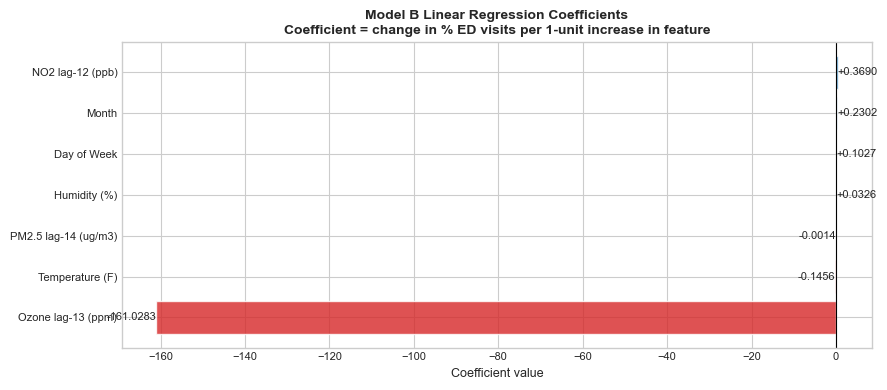

Saved: outputs/figures/model_03_feature_coefficients.png


In [9]:
# Plot 3: Feature coefficients
coef_df = pd.DataFrame([
    {'feature': FEATURE_LABELS.get(f, f), 'coefficient': c}
    for f, c in metrics_full['coefficients'].items()
]).sort_values('coefficient')

colors = ['#d62728' if c < 0 else '#1f77b4' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(coef_df['feature'], coef_df['coefficient'],
               color=colors, edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, coef_df['coefficient']):
    x = val + 0.002 if val >= 0 else val - 0.002
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=8)
ax.set_title(
    'Model B Linear Regression Coefficients\n'
    'Coefficient = change in % ED visits per 1-unit increase in feature',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Coefficient value', fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('outputs/figures/model_03_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_03_feature_coefficients.png')

---
## Step 5: Results Interpretation and Check-In Talking Points

In [10]:

print('MARCH CHECK-IN RESULTS SUMMARY')


print(f'''
Model: Linear Regression
Train period: {dates_train.min().date()} to {dates_train.max().date()}
Test period:  {dates_test.min().date()} to {dates_test.max().date()}

Results:
                        Model A         Model B
                    (env only)     (env + seasonal)
  Train R2:         {metrics_env["r2_train"]:.4f}          {metrics_full["r2_train"]:.4f}
  Test  R2:         {metrics_env["r2_test"]:.4f}          {metrics_full["r2_test"]:.4f}
  Test  RMSE:       {metrics_env["rmse_test"]:.4f} pp       {metrics_full["rmse_test"]:.4f} pp
  Test  MAE:        {metrics_env["mae_test"]:.4f} pp       {metrics_full["mae_test"]:.4f} pp
''')

print('Talking points for check-in:')
print()
print('1. What are we predicting?')
print('   Daily % of US ED visits classified as Acute Respiratory Illness.')
print('   We use % rather than raw counts to normalize for hospital capacity variation.')
print()
print('2. Why these features?')
print('   EDA revealed temperature is the strongest predictor (r = -0.812).')
print('   Lag analysis showed NO2 and Ozone have 12-13 day delayed effects')
print('   — consistent with respiratory illness incubation timelines.')
print('   Seasonal decomposition showed 81.4% of variance is seasonal,')
print('   which is why month is included as a feature.')
print()
print('3. Why linear regression first?')
print('   Establishes interpretable baseline. Coefficients directly show')
print('   each feature direction and magnitude. Sets a floor to beat.')
print()
print('4. Why is performance where it is?')
r2 = metrics_full['r2_test']
if r2 > 0.85:
    print('   Strong performance. Seasonal features captured most of the variance.')
elif r2 > 0.70:
    print('   Good baseline. Most seasonal variance is captured.')
    print('   Residuals show some structure — non-linear effects remain.')
    print('   Random Forest / XGBoost planned for April to capture these.')
else:
    print('   Moderate baseline. Linear model cannot capture non-linear')
    print('   seasonal interactions. Month as a linear feature is a simplification')
    print('   — a cyclic encoding or one-hot encoding would be more appropriate.')
    print('   Random Forest and XGBoost are planned for April check-in.')
print()


MARCH CHECK-IN RESULTS SUMMARY

Model: Linear Regression
Train period: 2022-10-09 to 2025-03-21
Test period:  2025-03-22 to 2025-10-31

Results:
                        Model A         Model B
                    (env only)     (env + seasonal)
  Train R2:         0.7544          0.7893
  Test  R2:         -0.6268          -0.6980
  Test  RMSE:       1.9291 pp       1.9708 pp
  Test  MAE:        1.5454 pp       1.4598 pp

Talking points for check-in:

1. What are we predicting?
   Daily % of US ED visits classified as Acute Respiratory Illness.
   We use % rather than raw counts to normalize for hospital capacity variation.

2. Why these features?
   EDA revealed temperature is the strongest predictor (r = -0.812).
   Lag analysis showed NO2 and Ozone have 12-13 day delayed effects
   — consistent with respiratory illness incubation timelines.
   Seasonal decomposition showed 81.4% of variance is seasonal,
   which is why month is included as a feature.

3. Why linear regression first?

---
## Summary

### Models trained

| Model | Features | Train R2 | Test R2 | Test RMSE |
|---|---|---|---|---|
| A — Environmental only | temperature, humidity, no2_lag12, ozone_lag13, pm25_lag14 | see output | see output | see output |
| B — Full | same + month + day_of_week | see output | see output | see output |

### Feature justification

| Feature | EDA finding | Direction |
|---|---|---|
| temperature | Strongest predictor r = -0.812, no lag | Cold = more illness |
| humidity | r = +0.530, no lag | Humid = more illness |
| no2_lag12 | r improves to 0.743 at lag-12 | High NO2 12 days ago = more illness |
| ozone_lag13 | r improves to -0.732 at lag-13 | High ozone 13 days ago = less illness |
| pm25_lag14 | Weakest, r = -0.153 at lag-14 | Minimal effect |
| month | 81.4% variance is seasonal | Captures annual cycle |
| day_of_week | Statistically significant ANOVA | Weekend effect |


